# Predicting Charging Duration

This notebook trains a regression model to predict the **true length of a charging session**
(`duration_hours`, in hours). It is Module C
of the EV Charging Intelligence & Optimization Platform and feeds the recommendation
engine in Phase 3.

> **Regression**
>
> Regression is supervised learning where the target is a continuous number. The model
> learns a function from the input features to that number and is judged by how far its
> predictions land from the truth, on data it did not see during training.

We compare four models of increasing flexibility:

1. **Mean baseline** — always predicts the training-set mean. Any real model must beat
   this to be worth keeping.
2. **Linear regression** — a weighted sum of the (scaled) features.
3. **Random forest** — an average of many decision trees, each trained on a bootstrap
   sample; captures non-linear effects and interactions.
4. **XGBoost** — gradient-boosted trees, built one at a time to correct the previous
   ensemble's errors.

and score them with three metrics (defined where they first appear): **MAE**, **RMSE**
and **R²**. Every random operation uses `random_state=42`.

## Contents

* What we predict, and which features are allowed
* Load the processed sessions
* Build the model matrix
* The mean baseline
* Train/test split
* Linear regression
* Random forest
* XGBoost
* 5-fold cross-validation: the honest comparison
* Hyperparameter tuning as an explicit loop
* Which features matter (SHAP)
* Interpretation and what it means for the platform
* Persist the model

## What we predict, and which features are allowed

The target is `duration_hours`. The predictors are restricted to **pre-session**
quantities — things known before the driver plugs in:

* vehicle: `vehicle_model` (one-hot), `battery_capacity_kwh`, `vehicle_age_years`
* request: `soc_start_pct`, `soc_end_pct`, `soc_delta_pct`, `distance_km`
* context: `temperature_c`, `charger_type_code`, `hour`, `weekday`, `is_weekend`,
  `location` (one-hot), `user_type` (one-hot)

Columns measured *during or after* the session — `charging_rate_kw`, the reported
duration, `cost_usd` — are excluded. Using them would leak information the recommendation
engine will not have and would flatter the metrics.

`duration_hours` is computed from the timestamps and is never missing, so all 1,320 rows are kept.

## Load the processed sessions

We start from `data/processed/sessions_clean.parquet`, the output of
`02_feature_engineering.ipynb`: canonical columns, engineered features and validation
flags, with missing values still present as `NaN`.

In [1]:
import sys

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd

from evcharging.config import CLEAN_PARQUET

df = pd.read_parquet(CLEAN_PARQUET)
df.shape

(1320, 57)

In [2]:
# The label and a few candidate predictors
df[["duration_hours", "battery_capacity_kwh", "soc_delta_pct", "distance_km"]].head()

,duration_hours,battery_capacity_kwh,soc_delta_pct,distance_km
0,0.650000,108.463007,56.748386,293.602111
1,2.016667,100.000000,74.548566,112.112804
2,2.800000,75.000000,63.063011,71.799253
3,3.700000,50.000000,16.504325,199.577785
4,1.766667,50.000000,9.484836,203.661847


In [3]:
print("missing labels:", df["duration_hours"].isna().sum())

missing labels: 0


## Build the model matrix

`prepare_xy` applies the missing-value policy from Phase 1: drop rows with a missing
label, then median-impute any remaining numeric predictor gaps (mostly `distance_km`) on
this modelling subset only. One-hot columns are picked up by prefix. We show the exact
steps and then confirm the packaged function produces the same matrix.

In [4]:
from evcharging.features import impute_predictors
from evcharging.models.regression import NUMERIC_PREDICTORS, predictor_columns

subset = df.dropna(subset=["duration_hours"]).reset_index(drop=True)
cols = predictor_columns(subset)

X = subset[cols].copy()
X = impute_predictors(X, numeric_cols=[c for c in NUMERIC_PREDICTORS if c in X]).astype(float)
y = subset["duration_hours"].astype(float)

X.shape, y.shape

((1320, 24), (1320,))

In [5]:
X.head()

,battery_capacity_kwh,soc_start_pct,soc_end_pct,soc_delta_pct,distance_km,temperature_c,vehicle_age_years,charger_type_code,hour,weekday,...,location_New York,location_San Francisco,user_type_Casual Driver,user_type_Commuter,user_type_Long-Distance Traveler,vehicle_model_BMW i3,vehicle_model_Chevy Bolt,vehicle_model_Hyundai Kona,vehicle_model_Nissan Leaf,vehicle_model_Tesla Model 3
0,108.463007,29.371576,86.119962,56.748386,293.602111,27.947953,2.0,2.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,100.000000,10.115778,84.664344,74.548566,112.112804,14.311026,3.0,0.0,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,75.000000,6.854604,69.917615,63.063011,71.799253,21.002002,2.0,1.0,2.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,50.000000,83.120003,99.624328,16.504325,199.577785,38.316313,1.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,50.000000,54.258950,63.743786,9.484836,203.661847,-7.834199,1.0,0.0,4.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [6]:
# No missing values remain, and every column is numeric
assert X.isna().sum().sum() == 0
assert X.select_dtypes(exclude="number").empty

In [7]:
from evcharging.models.regression import prepare_xy

X_pkg, y_pkg = prepare_xy(df, "duration_hours")
pd.testing.assert_frame_equal(X_pkg, X)
pd.testing.assert_series_equal(y_pkg, y)
print("packaged prepare_xy matches the manual steps")

packaged prepare_xy matches the manual steps


The model matrix is **1,320 rows × 24 features** — 11 numeric plus 13 one-hot
indicator columns. `y` is `duration_hours` in hours.

In [8]:
y.describe()

count    1320.000000
mean        2.225240
std         1.008414
min         0.500000
25%         1.379167
50%         2.183333
75%         3.083333
max         3.983333
Name: duration_hours, dtype: float64

The target ranges widely with a standard deviation of roughly 1 hour.
That spread is the yardstick: a useful model needs an MAE well below it.

## The mean baseline

> **Baseline model**
>
> A baseline is the simplest defensible predictor. Here it is `DummyRegressor(strategy=
> "mean")`, which ignores the features and always predicts the training mean. Its scores
> are the bar every other model has to clear; a model that cannot beat the baseline has
> learned nothing useful.

In [9]:
from sklearn.dummy import DummyRegressor

from evcharging.models.common import regression_metrics

baseline = DummyRegressor(strategy="mean")
baseline.fit(X, y)
regression_metrics(y, baseline.predict(X))

{'mae': 0.8729347451790634, 'rmse': 1.008031481502934, 'r2': 0.0}

> **MAE, RMSE, R²**
>
> **MAE** (mean absolute error) is the average absolute miss, in the target's units.
> **RMSE** (root mean squared error) squares the errors before averaging, so large
> misses count more; it is always ≥ MAE. **R²** is the share of the target's variance the
> model explains: 1.0 is perfect, 0.0 equals the mean baseline, negative is *worse* than
> the baseline.

By construction the baseline scores R² ≈ 0 on its own training data. The question for the
rest of the notebook is whether any model pushes R² meaningfully above 0 on held-out data.

## Train/test split

We hold out 25% of rows as a test set for the single-model sections below. The seed is
fixed so every run splits the same way. The definitive comparison later uses 5-fold
cross-validation instead, which uses every row for both training and testing across folds.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
X_train.shape, X_test.shape

((990, 24), (330, 24))

## Linear regression

> **Linear regression**
>
> Linear regression fits `y = w·x + b`, choosing the weights that minimise the sum of
> squared errors. It assumes the effect of each feature is additive and constant. We put
> a `StandardScaler` in front so every feature enters on the same scale and the weights
> are comparable.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

linreg = Pipeline([("scale", StandardScaler()), ("lr", LinearRegression())])
linreg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['battery_capacity_kwh','soc_start_pct','soc_end_pct',..., 'vehicle_model_Hyundai Kona','vehicle_model_Nissan Leaf', 'vehicle_model_Tesla Model 3']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [12]:
lin_pred = linreg.predict(X_test)
regression_metrics(y_test, lin_pred)

{'mae': 0.8390123760332692,
 'rmse': 0.9905202311720096,
 'r2': -0.03497000443149445}

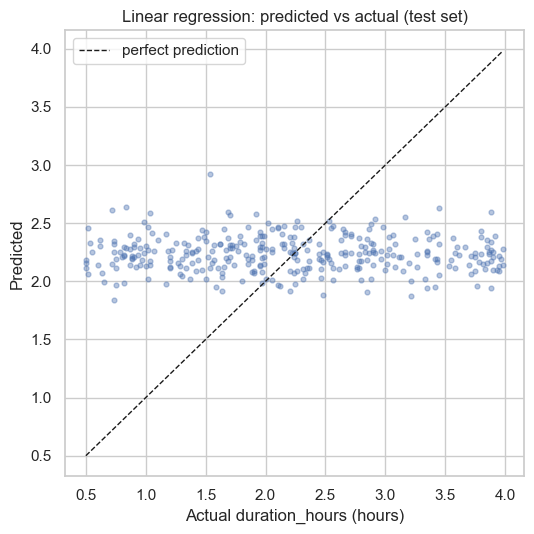

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

lo, hi = y_test.min(), y_test.max()
plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test, lin_pred, s=12, alpha=0.4)
plt.plot([lo, hi], [lo, hi], "k--", lw=1, label="perfect prediction")
plt.xlabel("Actual duration_hours (hours)")
plt.ylabel("Predicted")
plt.title("Linear regression: predicted vs actual (test set)")
plt.legend()
plt.tight_layout()
plt.show()

**Reading the plot.** The points form a horizontal band, not a diagonal. The model
predicts values close to the overall mean regardless of the inputs, because no linear
combination of the features tracks the target. The test-set R² is around zero or slightly
negative.

## Random forest

> **Random forest**
>
> A random forest trains many decision trees, each on a bootstrap sample of the rows and
> a random subset of features at each split, then averages their predictions. Averaging
> decorrelated trees lowers variance, and trees capture non-linear effects and
> interactions that linear regression cannot.

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=2, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [15]:
rf_pred = rf.predict(X_test)
regression_metrics(y_test, rf_pred)

{'mae': 0.841185657492059,
 'rmse': 0.991399073285192,
 'r2': -0.03680737980019866}

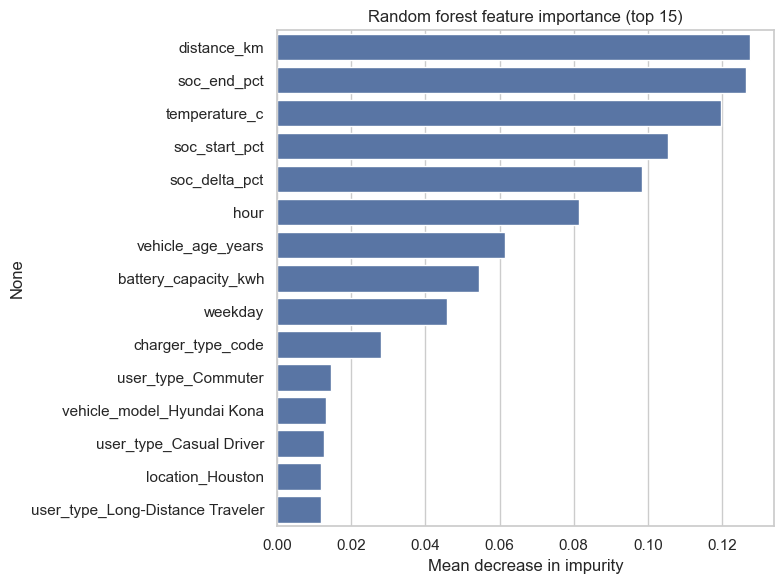

distance_km                         0.127651
soc_end_pct                         0.126438
temperature_c                       0.119603
soc_start_pct                       0.105300
soc_delta_pct                       0.098336
hour                                0.081384
vehicle_age_years                   0.061500
battery_capacity_kwh                0.054471
weekday                             0.045893
charger_type_code                   0.028041
user_type_Commuter                  0.014396
vehicle_model_Hyundai Kona          0.013221
user_type_Casual Driver             0.012585
location_Houston                    0.011884
user_type_Long-Distance Traveler    0.011752
dtype: float64

In [16]:
# Impurity-based feature importance, top 15
importance = (
    pd.Series(rf.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 6))
sns.barplot(x=importance.values, y=importance.index, color="#4C72B0")
plt.title("Random forest feature importance (top 15)")
plt.xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()
importance

**Reading the plot.** The importances are spread thinly across many features with no
dominant driver. The forest splits on whatever noise reduces training error, but those
splits do not generalise: the held-out R² is again around zero or negative, a sign of
mild overfitting to patterns that are not real.

## XGBoost

> **XGBoost**
>
> XGBoost builds trees sequentially. Each new tree is fit to the residual errors of the
> current ensemble, with regularisation and shrinkage (`learning_rate`) to control
> overfitting. On tabular data with genuine structure it is usually the strongest of
> these four models.

In [17]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1,
)
xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [18]:
xgb_pred = xgb.predict(X_test)
regression_metrics(y_test, xgb_pred)

{'mae': 0.8853437105573789,
 'rmse': 1.0513108592508973,
 'r2': -0.16590553290634213}

**Reading the result.** XGBoost does no better — often slightly worse — than the mean
baseline on the test set. When a well-tuned gradient-boosting model cannot beat a
constant, the usual cause is not the model but the data: the target does not depend on
the features.

## 5-fold cross-validation: the honest comparison

> **K-fold cross-validation**
>
> The data is split into k equal parts. Each part takes a turn as the test set while the
> other k−1 train the model, giving k out-of-sample scores. Averaging them uses every row
> for evaluation and makes the estimate far less sensitive to one lucky or unlucky split.

`kfold_regression` runs an explicit `KFold` loop (k = 5) and returns every fold's metrics
plus their mean and standard deviation. This is the comparison that decides which model,
if any, ships.

In [19]:
from evcharging.models.regression import make_model_factories
from evcharging.models.common import kfold_regression

factories = make_model_factories(random_state=42)
reports = {
    name: kfold_regression(name, factory, X, y, n_splits=5, random_state=42)
    for name, factory in factories.items()
}

comparison = pd.DataFrame({name: rep.as_dict() for name, rep in reports.items()}).T
comparison[["mae", "rmse", "r2", "mae_std"]]

,mae,rmse,r2,mae_std
baseline_mean,0.8736,1.0081,-0.0031,0.0365
linear_regression,0.8835,1.0208,-0.0289,0.0359
random_forest,0.8873,1.0275,-0.0416,0.0432
xgboost,0.9179,1.0755,-0.1419,0.0428


In [20]:
for rep in reports.values():
    print(rep.summary_row())

baseline_mean          MAE   0.874 +/- 0.037   RMSE   1.008   R2 -0.003
linear_regression      MAE   0.883 +/- 0.036   RMSE   1.021   R2 -0.029
random_forest          MAE   0.887 +/- 0.043   RMSE   1.027   R2 -0.042
xgboost                MAE   0.918 +/- 0.043   RMSE   1.076   R2 -0.142


**Observations**

* The **mean baseline has the lowest cross-validated MAE**. None of the three learned
  models beat it.
* Every learned model has a slightly **negative mean R²** — across folds they predict the
  target worse than a constant would.
* Fold-to-fold standard deviations are small, so this is a stable result, not a fluke of
  one split.

## Hyperparameter tuning as an explicit loop

> **Hyperparameter**
>
> A hyperparameter is a setting fixed before training rather than learned from data —
> tree depth, number of trees, learning rate. Tuning searches for the values that
> generalise best.

We sweep the random forest's `max_depth` in a plain loop, printing the training and
validation score at each setting so the **train/validation gap** is visible. A widening
gap with no validation gain is the signature of overfitting.

In [21]:
best_depth = None
best_val_mae = np.inf

for max_depth in [2, 3, 4, 6, 8, 12, None]:
    model = RandomForestRegressor(
        n_estimators=200, max_depth=max_depth, min_samples_leaf=2,
        random_state=42, n_jobs=-1,
    )
    model.fit(X_train, y_train)

    train_mae = regression_metrics(y_train, model.predict(X_train))["mae"]
    val_mae = regression_metrics(y_test, model.predict(X_test))["mae"]
    print(f"max_depth={str(max_depth):>4}  train MAE {train_mae:6.3f}   val MAE {val_mae:6.3f}")

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_depth = max_depth

print(f"\nbest max_depth by validation MAE: {best_depth}")

max_depth=   2  train MAE  0.871   val MAE  0.825


max_depth=   3  train MAE  0.857   val MAE  0.826


max_depth=   4  train MAE  0.836   val MAE  0.826


max_depth=   6  train MAE  0.774   val MAE  0.830


max_depth=   8  train MAE  0.687   val MAE  0.835


max_depth=  12  train MAE  0.509   val MAE  0.838


max_depth=None  train MAE  0.386   val MAE  0.843

best max_depth by validation MAE: 2


**Reading the loop.** Shallow trees (`max_depth` 2–3) have almost equal train and
validation error — both close to the baseline. As depth grows the training error falls
while the validation error does **not** improve: the model is fitting noise. The best
validation setting is a very shallow forest, which is another way of saying "predict
something close to the mean".

## Which features matter (SHAP)

> **SHAP values**
>
> SHAP (SHapley Additive exPlanations) assigns each feature a signed contribution to each
> individual prediction, based on cooperative game theory. Averaging the magnitudes over
> many rows gives a global importance ranking that, unlike impurity importance, is
> consistent and accounts for feature interactions.

We compute SHAP values for the XGBoost model on a sample of rows and save the summary
plot to `models/` for the README.

C:\Users\rumma\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


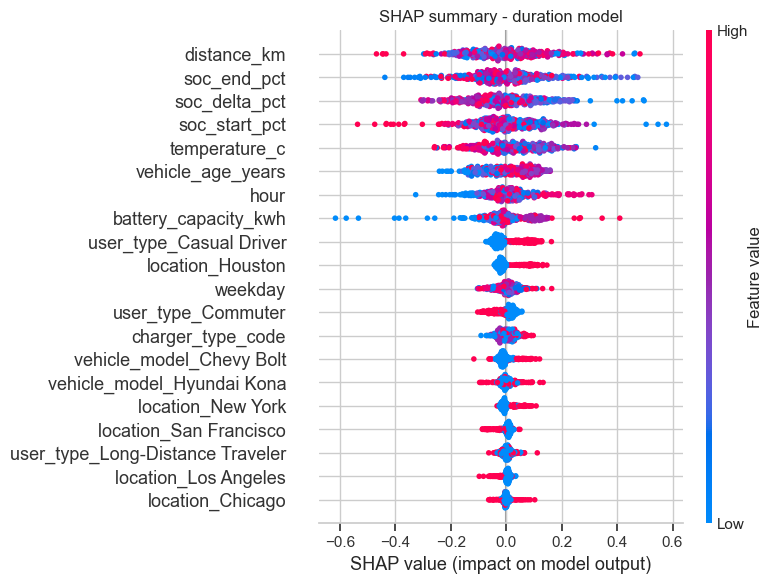

In [22]:
import shap

from evcharging.config import MODELS_DIR
from evcharging.models.regression import shap_summary_values

shap_values, sample = shap_summary_values(xgb, X, max_samples=400, random_state=42)

shap.summary_plot(shap_values, sample, show=False)
fig = plt.gcf()
fig.set_size_inches(8, 6)
plt.title("SHAP summary - duration model")
plt.tight_layout()
fig.savefig(MODELS_DIR / "shap_duration_summary.png", dpi=110, bbox_inches="tight")
plt.show()

**Reading the plot.** Every feature's SHAP values sit in a narrow band around zero. No
feature moves the prediction far in either direction, and there is no clean colour
gradient (high vs low feature value) — consistent with a target that does not respond to
any input.

## Interpretation and what it means for the platform

The `01_eda.ipynb` correlation heatmap already showed that `duration_hours` is essentially
uncorrelated with every other column (all |r| < 0.05). This notebook confirms the
consequence: **no model — linear, random forest, or gradient boosting — beats a constant
mean prediction** on this data. The synthetic dataset generated `duration_hours`
independently of the features, so there is no function to learn.

That is a legitimate and important result, not a failure of method:

* We compared against a baseline and cross-validated, so we can state the ceiling with
  confidence rather than shipping an overfit model that looks fine on one split.
* The model that ships is therefore the **mean predictor**. Its MAE
  (~0.87 h) is the honest expected error for any
  duration estimate on data like this.
* The Phase-3 recommendation engine uses this prediction as a **population average** and,
  where a physically meaningful estimate exists (for energy,
  `soc_delta/100 × battery_capacity`), reports that alongside it rather than pretending
  the ML model is personalised.

On a real charging dataset the same pipeline — same features, same four models, same
cross-validation — would surface whatever signal exists. Here it correctly reports that
there is none.

## Persist the model

`evcharging.models.duration.train()` re-runs the 5-fold comparison, refits the best model (the
baseline) on all rows, writes `duration_regressor.joblib` and updates the `"duration"`
section of `models/metrics.json`.

In [23]:
from evcharging.models.duration import train

result = train()
print("best model:", result.best_name)
result.metrics_payload()["cv"]

best model: baseline_mean


{'baseline_mean': {'name': 'baseline_mean',
  'cv_folds': 5,
  'mae': 0.8736,
  'rmse': 1.0081,
  'r2': -0.0031,
  'mae_std': 0.0365,
  'rmse_std': 0.031,
  'r2_std': 0.003},
 'linear_regression': {'name': 'linear_regression',
  'cv_folds': 5,
  'mae': 0.8835,
  'rmse': 1.0208,
  'r2': -0.0289,
  'mae_std': 0.0359,
  'rmse_std': 0.0284,
  'r2_std': 0.0158},
 'random_forest': {'name': 'random_forest',
  'cv_folds': 5,
  'mae': 0.8873,
  'rmse': 1.0275,
  'r2': -0.0416,
  'mae_std': 0.0432,
  'rmse_std': 0.0384,
  'r2_std': 0.0202},
 'xgboost': {'name': 'xgboost',
  'cv_folds': 5,
  'mae': 0.9179,
  'rmse': 1.0755,
  'r2': -0.1419,
  'mae_std': 0.0428,
  'rmse_std': 0.0396,
  'r2_std': 0.0381}}

In [24]:
from evcharging.models.common import load_artifact

reloaded = load_artifact("duration_regressor.joblib")
reloaded

,"strategy strategy: {""mean"", ""median"", ""quantile"", ""constant""}, default=""mean""Strategy to use to generate predictions.* ""mean"": always predicts the mean of the training set* ""median"": always predicts the median of the training set* ""quantile"": always predicts a specified quantile of the training set, provided with the quantile parameter.* ""constant"": always predicts a constant value that is provided by the user.",'mean'
,"constant constant: int or float or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
,"quantile quantile: float in [0.0, 1.0], default=NoneThe quantile to predict using the ""quantile"" strategy. A quantile of0.5 corresponds to the median, while 0.0 to the minimum and 1.0 to themaximum.",None
Name,Type,Value
"constant_ constant_: ndarray of shape (1, n_outputs)Mean or median or quantile of the training targets or constant valuegiven by the user.","ndarray[float64](1, 1)",[[2.23]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](24,)","['battery_capacity_kwh','soc_start_pct','soc_end_pct',..., 'vehicle_model_Hyundai Kona','vehicle_model_Nissan Leaf', 'vehicle_model_Tesla Model 3']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,24
n_outputs_ n_outputs_: intNumber of outputs.,int,1


## Summary / Key Takeaways

* The target `duration_hours` cannot be predicted from the available features on this
  dataset — a result established by comparing four models against a mean baseline with
  5-fold cross-validation.
* Linear regression, random forest and XGBoost all score a **slightly negative
  cross-validated R²**: worse than predicting the mean.
* The explicit `max_depth` sweep shows the tree models overfitting — training error falls,
  validation error does not.
* The shipped `duration_regressor.joblib` is the mean predictor, with an honest MAE of about
  0.87 hours.
* Method matters: the pipeline is correct and reusable; on data with real structure it
  would find it. Notebook `05_session_segmentation.ipynb`
  is next.